# Ejercicio Python 2: Simulación de inversión periódica (Dollar Cost Averaging)
# Eduardo Veytia H.

### Aplicar simulaciones para comparar dos estrategias de inversión: aportaciones periódicas frente a inversión única inicial.

### 1. Selecciona un activo financiero y descarga precios históricos de al menos 3 años.


In [47]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt

[*********************100%***********************]  1 of 1 completed


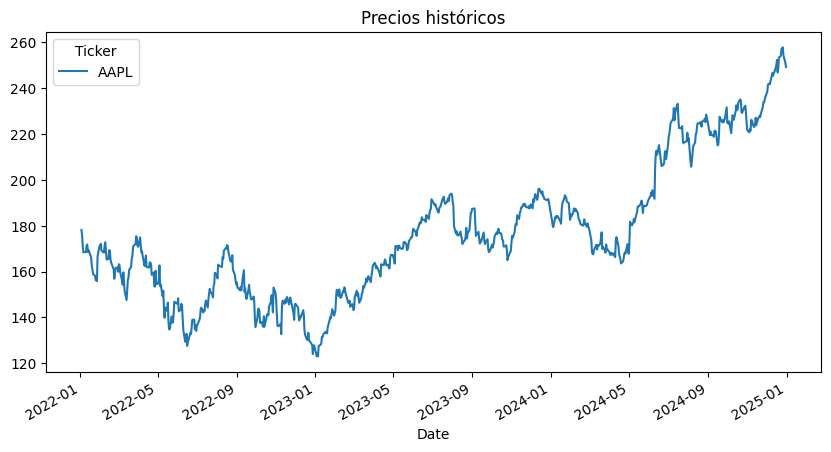

In [48]:
# Descarga de datos
tickers = ["AAPL"]

prices = yf.download(tickers, start='2022-01-01', end='2025-01-01')['Close']
prices.plot(figsize=(10,5),title="Precios históricos")
plt.show()

### 2. Define dos estrategias de inversión con un monto total de $5,000:

**Inversión única:** se invierte todo el monto al inicio del periodo.

**Inversión periódica (DCA):** se invierten $100 cada semana hasta completar $5,000.

In [49]:
#rendimientos diarios
rets = np.log(prices / prices.shift(1)).dropna()

mu = float(rets.mean())
sigma = float(rets.std())

print(f'mu diario: {mu:.6f}')
print(f'sigma diario: {sigma:.6f}')
print(f'mu anual: {mu*252:.4f}')
print(f'sigma anual: {sigma*np.sqrt(252):.4f}')

mu diario: 0.000446
sigma diario: 0.017038
mu anual: 0.1124
sigma anual: 0.2705


C:\Users\eduve\AppData\Local\Temp\ipykernel_20868\2019108958.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  mu = float(rets.mean())
C:\Users\eduve\AppData\Local\Temp\ipykernel_20868\2019108958.py:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  sigma = float(rets.std())


In [50]:
inv_a = 5000
inv_b = 100
n_weeks = inv_a // inv_b  #50 semanas
week = 5
total_days = n_weeks * week  #250 dias
n_sim = 10000
S0 = float(prices.iloc[-1])

print(f'S0: ${S0:.2f}')
print(f'Horizonte: {total_days} dias ({n_weeks} semanas)')
print(f'Simulaciones: {n_sim}')

S0: $249.06
Horizonte: 250 dias (50 semanas)
Simulaciones: 10000


C:\Users\eduve\AppData\Local\Temp\ipykernel_20868\486333843.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(prices.iloc[-1])


### 3. Simula 10,000 trayectorias de precios futuros usando Monte Carlo (con medias y desviaciones obtenidas de los datos).



In [51]:
np.random.seed(42)

drift = mu - 0.5 * sigma**2
Z = np.random.standard_normal((n_sim, total_days))

price_paths = np.zeros((n_sim, total_days + 1))
price_paths[:, 0] = S0

for t in range(1, total_days + 1):
    price_paths[:, t] = price_paths[:, t-1] * np.exp(drift + sigma * Z[:, t-1])

print(f'Precio final promedio: ${price_paths[:, -1].mean():.2f}')

Precio final promedio: $277.65


In [52]:
# $5000 Todo al inicio
shares_a = inv_a / S0
final_a = shares_a * price_paths[:, -1]
a_over_time = shares_a * price_paths

# $100 por semana
final_b = np.zeros(n_sim)
b_over_time = np.zeros((n_sim, total_days + 1))

for sim in range(n_sim):
    total_shares = 0
    for week in range(n_weeks):
        buy_day = week * 5
        total_shares += inv_b / price_paths[sim, buy_day]
        end = min((week + 1) * 5, total_days)
        for d in range(buy_day, end + 1):
            b_over_time[sim, d] = total_shares * price_paths[sim, d]
    for d in range(end, total_days + 1):
        b_over_time[sim, d] = total_shares * price_paths[sim, d]
    final_b[sim] = total_shares * price_paths[sim, -1]

### 4. Calcula y compara para ambas estrategias:

**a) Valor final promedio de la inversión.**

**b) Desviación estándar del valor final.**

**c) Probabilidad de que el valor final sea menor al capital invertido.|**

In [53]:
df_comp = pd.DataFrame({
    'Metrica': ['Valor final promedio', 'Mediana', 'Desv. Estandar', 'Minimo', 'Maximo', 'Percentil 5%', 'Percentil 95%', 'P(perdida)'],
    'a Sum': [
        final_a.mean(), np.median(final_a), final_a.std(),
        final_a.min(), final_a.max(),
        np.percentile(final_a, 5), np.percentile(final_a, 95),
        np.mean(final_a < inv_a)
    ],
    'b': [
        final_b.mean(), np.median(final_b), final_b.std(),
        final_b.min(), final_b.max(),
        np.percentile(final_b, 5), np.percentile(final_b, 95),
        np.mean(final_b < inv_a)
    ]
})
print(df_comp.to_string(index=False))

             Metrica        a Sum           b
Valor final promedio  5574.063119 5284.949450
             Mediana  5381.787638 5206.090812
      Desv. Estandar  1516.448129  844.324294
              Minimo  1932.096045 2919.372484
              Maximo 15064.035350 9580.544846
        Percentil 5%  3464.217218 4040.061959
       Percentil 95%  8355.899605 6757.027761
          P(perdida)     0.388600    0.400000


### 5. Construye gráficos:

**a) Histogramas comparativos de los valores finales.**

**b) Evolución promedio de la inversión bajo ambas estrategias.**


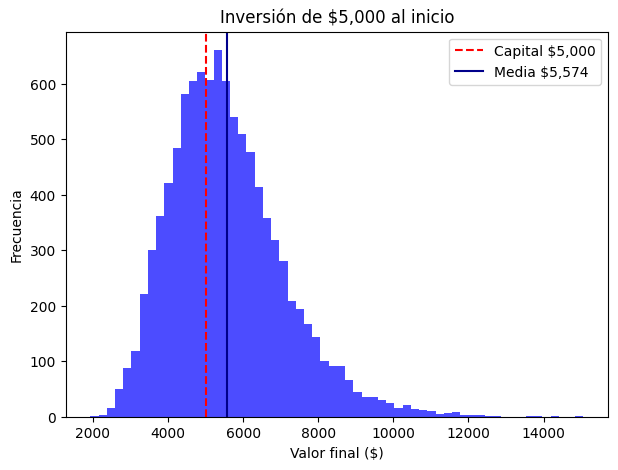

In [54]:
plt.figure(figsize=(7, 5))
plt.hist(final_a, bins=60, color='blue', alpha=0.7)
plt.axvline(inv_a, color='red', linestyle='--', label=f'Capital ${inv_a:,}')
plt.axvline(final_a.mean(), color='darkblue', label=f'Media ${final_a.mean():,.0f}')

plt.title('Inversión de $5,000 al inicio')
plt.xlabel('Valor final ($)')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

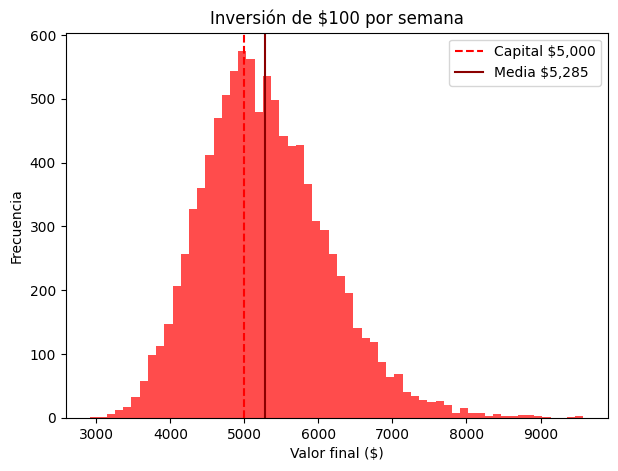

In [55]:
plt.figure(figsize=(7, 5))
plt.hist(final_b, bins=60, color='red', alpha=0.7)
plt.axvline(inv_a, color='red', linestyle='--', label=f'Capital ${inv_a:,}')
plt.axvline(final_b.mean(), color='darkred', label=f'Media ${final_b.mean():,.0f}')

plt.title('Inversión de $100 por semana')
plt.xlabel('Valor final ($)')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

In [56]:
# Calcular los promedios de las simulaciones
mean_a = np.mean(a_over_time, axis=0)
mean_b = np.mean(b_over_time, axis=0)

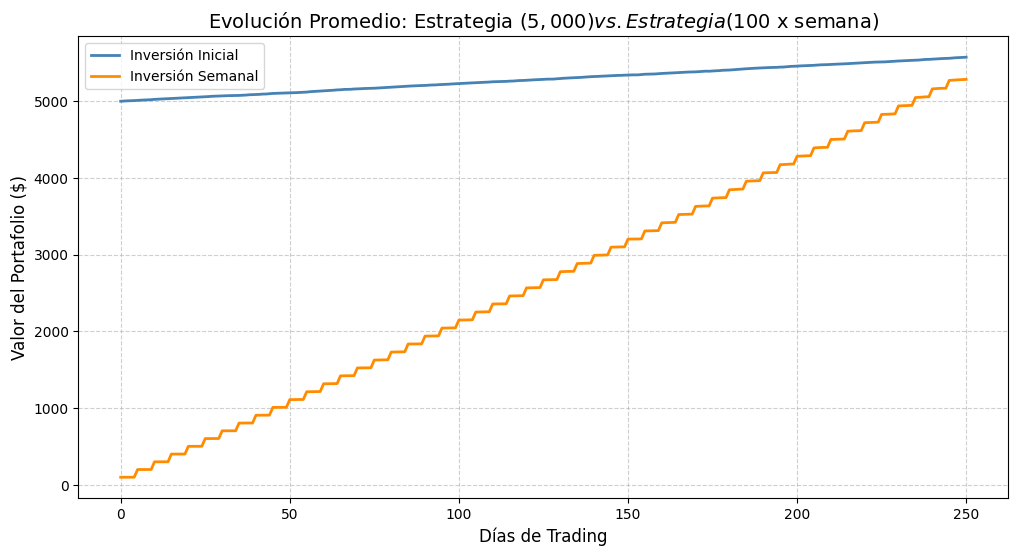

In [57]:
plt.figure(figsize=(12, 6))
plt.plot(mean_a, label='Inversión Inicial', color='steelblue', linewidth=2)
plt.plot(mean_b, label='Inversión Semanal', color='darkorange', linewidth=2)
plt.title('Evolución Promedio: Estrategia ($5,000) vs. Estrategia($100 x semana)', fontsize=14)
plt.xlabel('Días de Trading', fontsize=12)
plt.ylabel('Valor del Portafolio ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

### 6. Redacta un análisis breve, usando markdown en tu notebook, respondiendo:

**¿En qué condiciones es más ventajosa la inversión periódica?**

Mejor para controlar el riesgo y la psicología.

- Mercados volátiles: Compras más cuando el precio cae.

- Sin prisa: Evitas el error de invertir todo en un máximo histórico.

- Paz mental: Ideal si tienes aversión al riesgo o poco capital inicial.

- Ahorro mensual: Se ajusta a quienes invierten parte de su sueldo.

**¿Cuándo es preferible la inversión en un solo momento?**

Mejor para maximizar la rentabilidad histórica.

- Mercados alcistas: Aprovechas la subida desde el día uno.

- Mayor tiempo: El capital total genera intereses desde el inicio.

- Capital disponible: Ideal si ya tienes el dinero en mano.

- Sin esperas: Evitas que la inflación devore tu efectivo no invertido.